<a href="https://colab.research.google.com/github/abcsilence/AI_Model/blob/main/LearningDataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Supervised learning with scikit learn

> Add blockquote




In [ ]:
#Using sk-learn to fit a classifier
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
X = churn_df[["total_day_charge", "total_eve_charge"]].values
y = churn_df["churn"].values
print(X.shape, y.shape)

knn = KNeighborsClassifier(n_neighbors = 15)
knn.fit(X,y)

X_new =np.array([[56.8, 17.5],
                 [24.4, 24.1],
                 [50.1, 10.9]])

print(X_new.shape)

predictions = knn.predict(X_new)
print("Predictions: {}".format(predictions))


In [ ]:
# train, test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 21, stratify =y)
knn = KNeighborsClassifier(n_neighbors= 6)
knn.fit(X_train, y_train)
print(knn.score(X_test, y_test))

In [ ]:
train_accuracies = {}
test_accuracies = {}
neighbors = np.arange(1, 26)
for neighbor in neighbors:
  knn = KNeighborsClassifier(n_neighbors=neighbor)
  knn.fit(X_train, y_train)
  train_accuracies[neighbor] = knn.score(X_train, y_train)
  test_accuracies[neighbor] = knn.score(X_test, y_test)


In [ ]:
#Plot or resuts
plt.figure(figsize =(8,6))
plt.title("KNN: Varying Number of Neighbors")
plt.plot(neighbors, train_accuracies.values(), label= "Training Accuracy")
plt.plot(neighbors, test_accuracies.values(), label= "Testing Accuracy")
plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.show()


In [ ]:
# Regression
import pandas as pd
df = pd.read_csv("/content/diabetes.csv")
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
#Creating fature and target arrays
X = df.drop("Glucose", axis=1).values
y = df["Glucose"].values
print(type(X), type(y))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [ ]:
#Making predictions from a single feature

X_bmi = X[:, 3]
print(y.shape, X_bmi.shape)


(768,) (768,)


In [ ]:
#feature most me  2X2 matrxi
X_bmi = X_bmi.reshape(-1, 1)
print(X_bmi.shape)

(768, 1)


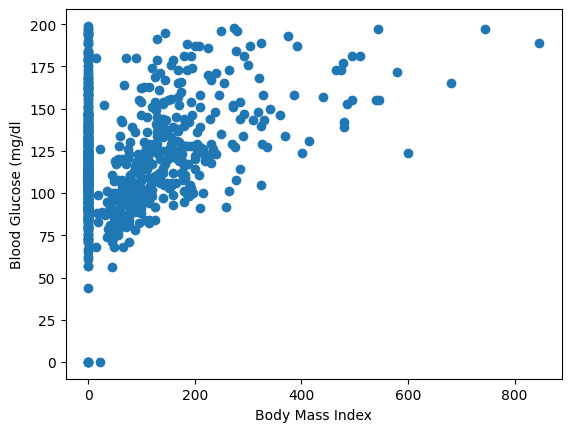

In [ ]:
# Plotting glucose vs.  body mass index
import matplotlib.pyplot as plt
plt.scatter(X_bmi , y)
plt.ylabel("Blood Glucose (mg/dl")
plt.xlabel("Body Mass Index")
plt.show()

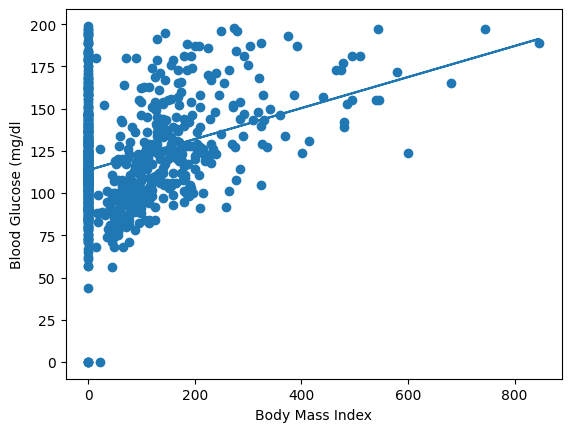

In [ ]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_bmi, y)
predictions = reg.predict(X_bmi)
plt.scatter(X_bmi, y)
plt.plot(X_bmi, predictions)
plt.ylabel("Blood Glucose (mg/dl")
plt.xlabel("Body Mass Index")
plt.show()

In [ ]:
#Linear Regression using all features
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
reg_all = LinearRegression()
reg_all.fit(X_train, y_train)
y_pred = reg_all.predict(X_test)

In [ ]:
# r^2 in scikit-learn

reg_all.score(X_test, y_test)


0.28280468810375115

In [ ]:
#RMSE in scikit-learn
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(y_test, y_pred)

26.341459582232265

In [ ]:
#Cross Validation
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
kf = KFold(n_splits = 6, shuffle = True, random_state = 42)
reg = LinearRegression()
cv_results = cross_val_score(reg, X, y, cv = kf)
print(cv_results)

print(np.mean(cv_results), np.std(cv_results))
print(np.quantile(cv_results, [0.025, 0.975]))


[0.26207548 0.28228176 0.41203082 0.23785884 0.41634629 0.30398869]
0.31909697867344794 0.070153206101142
[0.24088592 0.41580685]


In [ ]:
#Ridge regression in scikit-learn

from sklearn.linear_model import Ridge
scores = []
for alpha in [0.1, 1.0, 10.0, 100.0, 1000.0]:
  ridge = Ridge(alpha = alpha)
  ridge.fit(X_train, y_train)
  y_pred = ridge.predict(X_test)
  scores.append(ridge.score(X_test, y_test))

print(scores)

[0.2828466623222221, 0.28320633574804766, 0.2853000732200006, 0.26423984812668133, 0.19292424694100963]


In [ ]:
#Lasso Regression

from sklearn.linear_model import  Lasso
scores = []
for alpha in [0.01, 1.0, 10.0, 20.0, 50.0]:
  lasso = Lasso(alpha = alpha)
  lasso.fit(X_train, y_train)
  lasso_pred = lasso.predict(X_test)
  scores.append(lasso.score(X_test, y_test))

print(scores)

[0.2831114455475573, 0.29795609755827845, 0.17989838789273893, 0.18127361610181125, 0.15679544303617987]


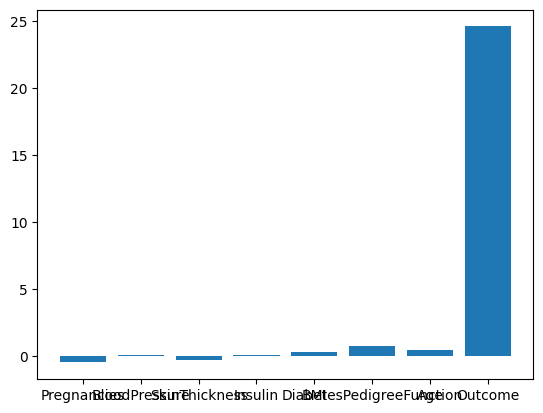

In [ ]:
#Lasso For feature selection in scikit-learn
import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
X = df.drop("Glucose", axis = 1).values
y = df["Glucose"].values
name  = df.drop("Glucose", axis = 1).columns
lasso = Lasso(alpha=0.1)
lasso_coef = lasso.fit(X,y).coef_
plt.bar(name, lasso_coef)
# plt.xtricks(rotation = 45)
plt.show()

In [ ]:
#Confusion Matrix. in scikit-learn

from sklearn.metrics import classification_report, confusion_matrix
knn = KNeighborsClassifier(n_neighbors = 7)
X_train , X_test, y_train, y_test = train_test_split(X,y, test_size = 0.4, random_state = 42)
knn.fit(X_train, y_train)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))



In [ ]:
#Logistic regression in scikit-learn

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)
logreg.fit(X_train , y_train)

y_pred = logreg.predict(X_test)

#predicting probabilities

y_pred_probs = logreg.predict_proba(X_test)[:, 1]
print(y_pred_probs[0])



In [ ]:
#Ploting the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
plt.plot([0,1],[0,1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel("False positive Rate")
plt.ylabel("True positive Rate")
plt.title("Logistic Regression ROC Curve")
plt.show()

In [ ]:
#ROC AUC in sk-learn
from sklearn.metrics import roc_auc_score
print(roc_auc_score(y_test, y_pred_probs))


In [ ]:
#Grid SearchCV in sklearn

from sklearn.model_selection import GridSearchCV
kf= KFold(n_splits - 5, shuffle = True, random_state = 42)
param_grid = {"alpha": np.arange(0.0001. 1. 10),
              "solver":["sag", "lsqr"]}

ridge = Ridge()
ridge_cv = GridSearchCV(ridge, param_grid, cv = kf)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_scores_)


In [ ]:
#RandomizedSearch CV
from sklearn.model_selection import RandomizedSearchCV
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)
param_grid = {"alpha": np.arange(0.0001, 1, 10),
              "solver":["sag", "lsqr"] }

 ridge = Ridge()
ridge_cv = RandomizedSearchCV(ridge, param_grid, cv = kf, n_iter = 2)
ridge_cv.fit(X_train, y_train)
print(ridge_cv.best_params_, ridge_cv.best_scores_)

#Evaluating on the test set

test_score  = ridge_cv.score(X_test, y_test)
print(test_score

In [ ]:
#Preprocessing data

#Encoding dummy variables using get_dummies


In [ ]:
#Evaluating classification models for the binary classification

import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

X= music.drop("genre", axis = 1).values
y = music["genre"].values
X_train, y_train, X_test, y_test = train_test_split(X,y, random_state = 42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)


#models

models = {"Logistic Regression": LogisticRegression(), "KNN": KNeighborsClassifier(),
          "Decision Tree": DecisionTreeClassifier}

results = []
for model in models.values()
    kf = KFold(n_splits = 6, random_state = 42, shuffle = True)
    cv_results = cross_val_score(model, X_train_scaled, y_train, cv =kf)
    results.append(cv_results)

plt.boxplot(results, labels = models.keys())
plt.show()

In [ ]:
#Test set performance
for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  test_score = model.score(X_test_scaled, y_test)
  print("{} Test Set Accuracy: {}".format(name, test_score))



##Unsupervised learning

In [ ]:
#using k mean
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 3)
model.fit(samples)

label = model.predict(samples)
print(label)

#Assign the new sample

new_labels = model.predict(new_samples)
print(new_labels)


#Scatter plots
import matplotlib.pyplot as plt
xs = samples[:, 0]
ys = samples[:, 2]
plt.scatter(xs, ys, c = labels)
plt.show()

In [ ]:
import padas as pd
df.DataFrame({'labels': labels, 'species': species})
print(df )

#Pandas cross tab function to build the cross tabulation
ct = pd.crosstab(df['labels'], df['species'])
print(ct)

In [ ]:
#Inertia measures clustering quality
from sklearn.cluster import KMeans
model = KMeans(n_clusters=3)
model.fit(samples)
print(model.inertia_)


In [ ]:
#Clustering the wines
from sklearn.cluster import KMeans
model = KMeans(n_clusters = 3)
labels = model.fit_predict(samples)

#Cluster vs varities

df = pd.DataFrame({'labels': labels, 'varieties': varieties})

ct = pd.crosstab(df['labesl'], df['varieties'])
print(ct)

#Sklearn StandardScaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(samples)
StandardScaler(copy = True, with_mean =True,  with_std= True)
samples_scaled = scaler.transform(samples)



In [ ]:
#Pipelines combine multiple steps

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
scaler = StandardScaler()
kmeans = KMeans(n_clusters= 3)
from sklearn.pipeline import make_pipeline
pipeline = make_pipeline(scaler, kmeans)
pipeline.fit(samples)

labels = pipeline.predict(samples)


In [ ]:
#Heirarchical clustering with SciPy

import matplotlib.pyplot as plt
from scipy.cluster.heirarchy import linkage, dendogram
merging = linkage(samples, method = 'complete')
dendogram(mergings, labels = country_names, leaf_rotation - 90, leaf_font_size= 6)
plt.show()

In [ ]:
#Extracting cluster labels using fcluster

from scipy.cluster.hierarchy import linkage
mergins = linkage(samples, method = 'complete')
from scipy.cluster.hierarchy import fcluster
labels, = fcluster(mergins, 15, criterion = 'distance')
print(labels)

In [ ]:
#Aligning cluster labels with country names

import pandas as pd
pairs = pd.DataFrame({'labels': labels, 'coutries': country_names})
print(pairs.sort_values('labels'))

In [ ]:
#t-SNE in sklern
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
model = TSNE(learning_rate= 100)
transformed = model.fit